##Problem Statement:Build a machine learning solution to predict the market value of a football player using the given features.

In [2]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


####Load the Dataset

In [3]:
df = pd.read_csv("/content/player_stats.csv.csv", encoding='latin1')

In [4]:
df

,player,country,height,weight,age,club,ball_control,dribbling,marking,slide_tackle,...,curve,fk_acc,penalties,volleys,gk_positioning,gk_diving,gk_handling,gk_kicking,gk_reflexes,value
0,Cristian Castro Devenish,Colombia,192,84,22,Atl. Nacional,55,43,NaN,68,...,32,34,41,33,10,11,6,7,9,$1.400.000
1,Silaldo Taffarel,Brazil,181,80,31,Corinthians,69,70,NaN,56,...,65,62,48,46,12,15,14,8,14,$975.00
2,Thomas DÃ¤hne,Germany,193,84,29,Holstein Kiel,25,12,NaN,13,...,20,15,26,16,64,74,65,68,74,$1.100.000
3,Michael Sollbauer,Austria,187,86,33,SK Rapid Wien,46,48,NaN,66,...,25,13,22,19,10,10,8,14,9,$650.00
4,Diego Segovia,Uruguay,191,80,23,Independiente,14,8,NaN,14,...,9,10,16,5,61,59,62,64,64,$300.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5677,Mohamed Salah,Egypt,175,71,31,Liverpool,86,88,NaN,41,...,84,69,86,83,11,14,14,9,14,$99.500.000
5678,Sadio Mané,Senegal,174,69,31,FC Bayern München,86,88,NaN,38,...,77,64,75,75,7,10,10,15,14,$101.000.000
5679,Neymar Jr,Brazil,175,68,31,Paris SG,94,95,NaN,29,...,88,87,91,86,15,9,9,15,11,$99.500.000
5680,Cristiano Ronaldo,Portugal,187,83,38,Al Nassr,87,81,NaN,24,...,79,75,90,85,14,7,11,15,11,$31.000.000


##Basic Data Check

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5682 entries, 0 to 5681
Data columns (total 41 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   player          5682 non-null   object 
 1   country         5682 non-null   object 
 2   height          5682 non-null   int64  
 3   weight          5682 non-null   int64  
 4   age             5682 non-null   int64  
 5   club            5682 non-null   object 
 6   ball_control    5682 non-null   int64  
 7   dribbling       5682 non-null   int64  
 8   marking         0 non-null      float64
 9   slide_tackle    5682 non-null   int64  
 10  stand_tackle    5682 non-null   int64  
 11  aggression      5682 non-null   int64  
 12  reactions       5682 non-null   int64  
 13  att_position    5682 non-null   int64  
 14  interceptions   5682 non-null   int64  
 15  vision          5682 non-null   int64  
 16  composure       5682 non-null   int64  
 17  crossing        5682 non-null   i

we get to know info about the dataset

In [6]:
df.describe()

,height,weight,age,ball_control,dribbling,marking,slide_tackle,stand_tackle,aggression,reactions,...,long_shots,curve,fk_acc,penalties,volleys,gk_positioning,gk_diving,gk_handling,gk_kicking,gk_reflexes
count,5682.000000,5682.000000,5682.000000,5682.000000,5682.000000,0.0,5682.000000,5682.000000,5682.000000,5682.000000,...,5682.000000,5682.000000,5682.000000,5682.000000,5682.000000,5682.000000,5682.00000,5682.000000,5682.000000,5682.000000
mean,181.670539,75.282295,26.316262,58.912179,56.128476,NaN,46.728441,48.820838,56.324006,61.959345,...,47.164203,48.099789,43.299542,48.174938,42.931890,16.187610,16.43805,16.191834,16.071982,16.570222
std,6.829238,6.998971,4.729967,16.567068,18.772075,NaN,20.519430,20.975966,16.846410,8.893309,...,19.463368,18.086672,17.086473,15.781737,17.912619,17.146572,17.63526,16.993154,16.808674,17.942154
min,156.000000,54.000000,17.000000,8.000000,5.000000,NaN,7.000000,7.000000,11.000000,32.000000,...,5.000000,7.000000,4.000000,8.000000,4.000000,2.000000,2.00000,2.000000,2.000000,3.000000
25%,177.000000,70.000000,23.000000,55.000000,51.000000,NaN,27.000000,30.000000,45.000000,56.000000,...,33.000000,36.000000,32.000000,39.000000,30.000000,8.000000,8.00000,8.000000,8.000000,8.000000
50%,182.000000,75.000000,26.000000,63.000000,62.000000,NaN,54.000000,57.000000,60.000000,62.000000,...,51.000000,50.000000,43.000000,49.000000,44.000000,11.000000,11.00000,11.000000,11.000000,11.000000
75%,186.000000,80.000000,30.000000,69.000000,68.000000,NaN,64.000000,66.000000,69.000000,68.000000,...,62.000000,62.000000,56.000000,60.000000,57.000000,14.000000,14.00000,14.000000,14.000000,14.000000
max,204.000000,102.000000,41.000000,94.000000,95.000000,NaN,87.000000,91.000000,96.000000,93.000000,...,91.000000,93.000000,94.000000,92.000000,90.000000,90.000000,90.00000,87.000000,90.000000,89.000000


This describes about the dataset

In [7]:
df.head()

,player,country,height,weight,age,club,ball_control,dribbling,marking,slide_tackle,...,curve,fk_acc,penalties,volleys,gk_positioning,gk_diving,gk_handling,gk_kicking,gk_reflexes,value
0,Cristian Castro Devenish,Colombia,192,84,22,Atl. Nacional,55,43,NaN,68,...,32,34,41,33,10,11,6,7,9,$1.400.000
1,Silaldo Taffarel,Brazil,181,80,31,Corinthians,69,70,NaN,56,...,65,62,48,46,12,15,14,8,14,$975.00
2,Thomas DÃ¤hne,Germany,193,84,29,Holstein Kiel,25,12,NaN,13,...,20,15,26,16,64,74,65,68,74,$1.100.000
3,Michael Sollbauer,Austria,187,86,33,SK Rapid Wien,46,48,NaN,66,...,25,13,22,19,10,10,8,14,9,$650.00
4,Diego Segovia,Uruguay,191,80,23,Independiente,14,8,NaN,14,...,9,10,16,5,61,59,62,64,64,$300.00


It gives top 5 rows

In [8]:
df.tail()

,player,country,height,weight,age,club,ball_control,dribbling,marking,slide_tackle,...,curve,fk_acc,penalties,volleys,gk_positioning,gk_diving,gk_handling,gk_kicking,gk_reflexes,value
5677,Mohamed Salah,Egypt,175,71,31,Liverpool,86,88,NaN,41,...,84,69,86,83,11,14,14,9,14,$99.500.000
5678,Sadio Mané,Senegal,174,69,31,FC Bayern München,86,88,NaN,38,...,77,64,75,75,7,10,10,15,14,$101.000.000
5679,Neymar Jr,Brazil,175,68,31,Paris SG,94,95,NaN,29,...,88,87,91,86,15,9,9,15,11,$99.500.000
5680,Cristiano Ronaldo,Portugal,187,83,38,Al Nassr,87,81,NaN,24,...,79,75,90,85,14,7,11,15,11,$31.000.000
5681,Zlatan Ibrahimovi?,Sweden,195,102,41,Milan,85,75,NaN,24,...,79,74,80,87,9,13,15,10,12,$10.500.000


It gives us bottom 5 rows

In [9]:
df.shape

(5682, 41)

It describes  no of rows and columns

In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
height,5682.0,181.670539,6.829238,156.0,177.0,182.0,186.0,204.0
weight,5682.0,75.282295,6.998971,54.0,70.0,75.0,80.0,102.0
age,5682.0,26.316262,4.729967,17.0,23.0,26.0,30.0,41.0
ball_control,5682.0,58.912179,16.567068,8.0,55.0,63.0,69.0,94.0
dribbling,5682.0,56.128476,18.772075,5.0,51.0,62.0,68.0,95.0
marking,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
slide_tackle,5682.0,46.728441,20.519430,7.0,27.0,54.0,64.0,87.0
stand_tackle,5682.0,48.820838,20.975966,7.0,30.0,57.0,66.0,91.0
aggression,5682.0,56.324006,16.846410,11.0,45.0,60.0,69.0,96.0
reactions,5682.0,61.959345,8.893309,32.0,56.0,62.0,68.0,93.0


Transform is used here.It transforms the dataset.

In [11]:
## DROP player and club column

df.drop(["player","club"], axis=1, inplace= True)

Player and Club are the unique columns in the dataset so we can drop them.

In [12]:
df

,country,height,weight,age,ball_control,dribbling,marking,slide_tackle,stand_tackle,aggression,...,curve,fk_acc,penalties,volleys,gk_positioning,gk_diving,gk_handling,gk_kicking,gk_reflexes,value
0,Colombia,192,84,22,55,43,NaN,68,73,72,...,32,34,41,33,10,11,6,7,9,$1.400.000
1,Brazil,181,80,31,69,70,NaN,56,58,62,...,65,62,48,46,12,15,14,8,14,$975.00
2,Germany,193,84,29,25,12,NaN,13,16,27,...,20,15,26,16,64,74,65,68,74,$1.100.000
3,Austria,187,86,33,46,48,NaN,66,69,71,...,25,13,22,19,10,10,8,14,9,$650.00
4,Uruguay,191,80,23,14,8,NaN,14,16,28,...,9,10,16,5,61,59,62,64,64,$300.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5677,Egypt,175,71,31,86,88,NaN,41,43,63,...,84,69,86,83,11,14,14,9,14,$99.500.000
5678,Senegal,174,69,31,86,88,NaN,38,42,75,...,77,64,75,75,7,10,10,15,14,$101.000.000
5679,Brazil,175,68,31,94,95,NaN,29,32,63,...,88,87,91,86,15,9,9,15,11,$99.500.000
5680,Portugal,187,83,38,87,81,NaN,24,32,62,...,79,75,90,85,14,7,11,15,11,$31.000.000


In [13]:
# Null value check

df.isnull().sum()

,0
country,0
height,0
weight,0
age,0
ball_control,0
dribbling,0
marking,5682
slide_tackle,0
stand_tackle,0
aggression,0


There are no null values present

In [14]:
## Check for duplicates

df.duplicated().sum()

np.int64(5)

In [15]:
df.drop_duplicates()

,country,height,weight,age,ball_control,dribbling,marking,slide_tackle,stand_tackle,aggression,...,curve,fk_acc,penalties,volleys,gk_positioning,gk_diving,gk_handling,gk_kicking,gk_reflexes,value
0,Colombia,192,84,22,55,43,NaN,68,73,72,...,32,34,41,33,10,11,6,7,9,$1.400.000
1,Brazil,181,80,31,69,70,NaN,56,58,62,...,65,62,48,46,12,15,14,8,14,$975.00
2,Germany,193,84,29,25,12,NaN,13,16,27,...,20,15,26,16,64,74,65,68,74,$1.100.000
3,Austria,187,86,33,46,48,NaN,66,69,71,...,25,13,22,19,10,10,8,14,9,$650.00
4,Uruguay,191,80,23,14,8,NaN,14,16,28,...,9,10,16,5,61,59,62,64,64,$300.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5676,France,185,81,35,91,87,NaN,18,24,63,...,82,73,84,88,5,13,11,5,7,$64.000.000
5677,Egypt,175,71,31,86,88,NaN,41,43,63,...,84,69,86,83,11,14,14,9,14,$99.500.000
5679,Brazil,175,68,31,94,95,NaN,29,32,63,...,88,87,91,86,15,9,9,15,11,$99.500.000
5680,Portugal,187,83,38,87,81,NaN,24,32,62,...,79,75,90,85,14,7,11,15,11,$31.000.000


5 Duplicates were found in the dataset so we then dropped the duplicates using the above step

##Split the dataset into categorical and numerical column

In [16]:
categorical_columns = df.select_dtypes(include = "object").columns
numerical_columns  = df.select_dtypes(exclude = "object").columns

In [17]:
categorical_columns

Index(['country', 'value'], dtype='object')

Displays categorical columns

In [18]:
numerical_columns

Index(['height', 'weight', 'age', 'ball_control', 'dribbling', 'marking',
       'slide_tackle', 'stand_tackle', 'aggression', 'reactions',
       'att_position', 'interceptions', 'vision', 'composure', 'crossing',
       'short_pass', 'long_pass', 'acceleration', 'stamina', 'strength',
       'balance', 'sprint_speed', 'agility', 'jumping', 'heading',
       'shot_power', 'finishing', 'long_shots', 'curve', 'fk_acc', 'penalties',
       'volleys', 'gk_positioning', 'gk_diving', 'gk_handling', 'gk_kicking',
       'gk_reflexes'],
      dtype='object')

Displays numerical columns

In [19]:
df

,country,height,weight,age,ball_control,dribbling,marking,slide_tackle,stand_tackle,aggression,...,curve,fk_acc,penalties,volleys,gk_positioning,gk_diving,gk_handling,gk_kicking,gk_reflexes,value
0,Colombia,192,84,22,55,43,NaN,68,73,72,...,32,34,41,33,10,11,6,7,9,$1.400.000
1,Brazil,181,80,31,69,70,NaN,56,58,62,...,65,62,48,46,12,15,14,8,14,$975.00
2,Germany,193,84,29,25,12,NaN,13,16,27,...,20,15,26,16,64,74,65,68,74,$1.100.000
3,Austria,187,86,33,46,48,NaN,66,69,71,...,25,13,22,19,10,10,8,14,9,$650.00
4,Uruguay,191,80,23,14,8,NaN,14,16,28,...,9,10,16,5,61,59,62,64,64,$300.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5677,Egypt,175,71,31,86,88,NaN,41,43,63,...,84,69,86,83,11,14,14,9,14,$99.500.000
5678,Senegal,174,69,31,86,88,NaN,38,42,75,...,77,64,75,75,7,10,10,15,14,$101.000.000
5679,Brazil,175,68,31,94,95,NaN,29,32,63,...,88,87,91,86,15,9,9,15,11,$99.500.000
5680,Portugal,187,83,38,87,81,NaN,24,32,62,...,79,75,90,85,14,7,11,15,11,$31.000.000


In [20]:
## Count the values in each of the categories

for i in categorical_columns:
  print(df[i].value_counts())
  print('--'*50)

country
England               516
Germany               390
Spain                 356
France                309
Argentina             302
                     ... 
Honduras                1
St Lucia                1
Kazakhstan              1
Gibraltar               1
Dominican Republic      1
Name: count, Length: 135, dtype: int64
----------------------------------------------------------------------------------------------------
value
$1.200.000     182
$1.100.000     166
$1.000.000     143
$1.300.000     133
$1.600.000     129
              ... 
$97.000.000      1
$10.00           1
$77.000.000      1
$64.000.000      1
$31.000.000      1
Name: count, Length: 191, dtype: int64
----------------------------------------------------------------------------------------------------


In [21]:
df

,country,height,weight,age,ball_control,dribbling,marking,slide_tackle,stand_tackle,aggression,...,curve,fk_acc,penalties,volleys,gk_positioning,gk_diving,gk_handling,gk_kicking,gk_reflexes,value
0,Colombia,192,84,22,55,43,NaN,68,73,72,...,32,34,41,33,10,11,6,7,9,$1.400.000
1,Brazil,181,80,31,69,70,NaN,56,58,62,...,65,62,48,46,12,15,14,8,14,$975.00
2,Germany,193,84,29,25,12,NaN,13,16,27,...,20,15,26,16,64,74,65,68,74,$1.100.000
3,Austria,187,86,33,46,48,NaN,66,69,71,...,25,13,22,19,10,10,8,14,9,$650.00
4,Uruguay,191,80,23,14,8,NaN,14,16,28,...,9,10,16,5,61,59,62,64,64,$300.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5677,Egypt,175,71,31,86,88,NaN,41,43,63,...,84,69,86,83,11,14,14,9,14,$99.500.000
5678,Senegal,174,69,31,86,88,NaN,38,42,75,...,77,64,75,75,7,10,10,15,14,$101.000.000
5679,Brazil,175,68,31,94,95,NaN,29,32,63,...,88,87,91,86,15,9,9,15,11,$99.500.000
5680,Portugal,187,83,38,87,81,NaN,24,32,62,...,79,75,90,85,14,7,11,15,11,$31.000.000


## Handling error "?" values in the dataset

In [22]:
df.isin(['?']).sum()

,0
country,0
height,0
weight,0
age,0
ball_control,0
dribbling,0
marking,0
slide_tackle,0
stand_tackle,0
aggression,0


In [23]:
df['value'] = df['value'].astype(str).str.replace('$', '', regex=False).str.replace('.', '', regex=False)
df['value'] = pd.to_numeric(df['value'])
display(df.head())

,country,height,weight,age,ball_control,dribbling,marking,slide_tackle,stand_tackle,aggression,...,curve,fk_acc,penalties,volleys,gk_positioning,gk_diving,gk_handling,gk_kicking,gk_reflexes,value
0,Colombia,192,84,22,55,43,NaN,68,73,72,...,32,34,41,33,10,11,6,7,9,1400000
1,Brazil,181,80,31,69,70,NaN,56,58,62,...,65,62,48,46,12,15,14,8,14,97500
2,Germany,193,84,29,25,12,NaN,13,16,27,...,20,15,26,16,64,74,65,68,74,1100000
3,Austria,187,86,33,46,48,NaN,66,69,71,...,25,13,22,19,10,10,8,14,9,65000
4,Uruguay,191,80,23,14,8,NaN,14,16,28,...,9,10,16,5,61,59,62,64,64,30000


####outlier Detection

In [24]:
for col in df.select_dtypes(include=np.number).columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = np.where(df[col] < lower, lower, df[col])
    df[col] = np.where(df[col] > upper, upper, df[col])

In [25]:
print(df.shape)

(5682, 39)


##Univariate analysis

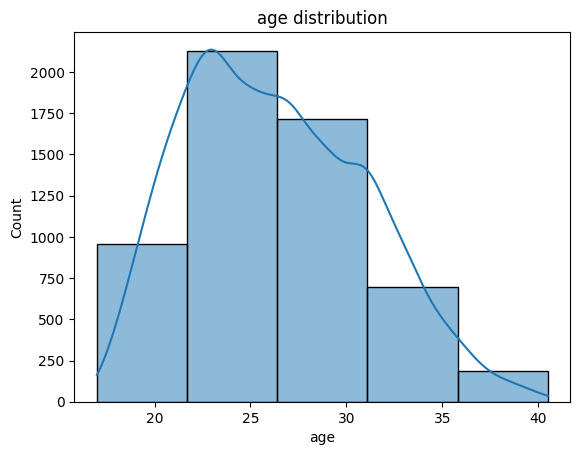

In [26]:
sns.histplot(df['age'], kde = True, bins =5)
plt.title("age distribution")
plt.show()

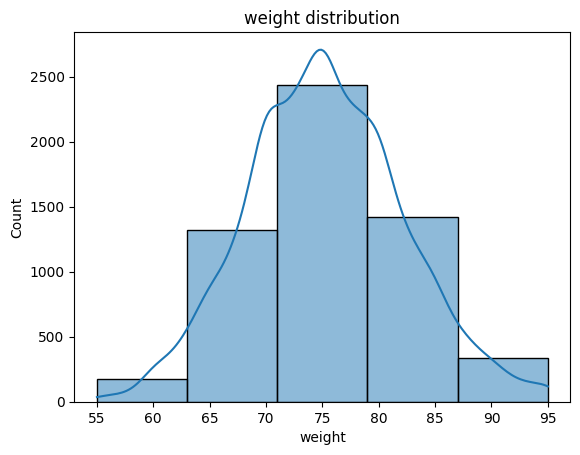

In [27]:
sns.histplot(df['weight'], kde = True, bins =5)
plt.title("weight distribution")
plt.show()

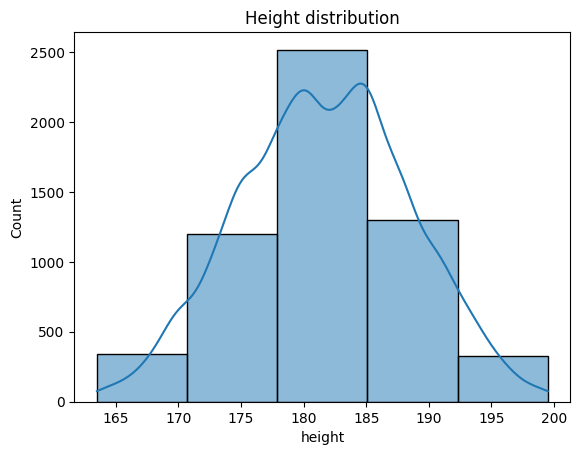

In [28]:
sns.histplot(df['height'], kde = True, bins =5)
plt.title("Height distribution")
plt.show()

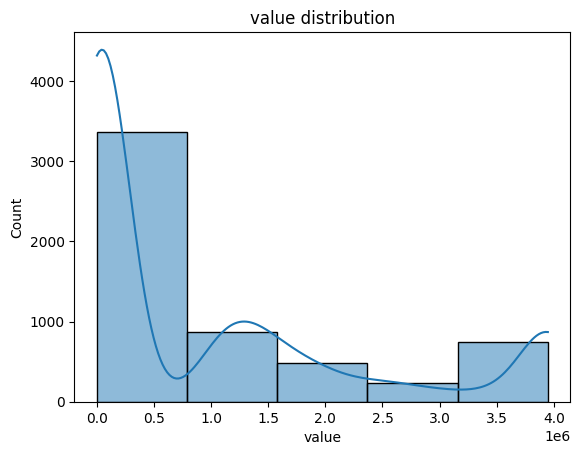

In [29]:
sns.histplot(df['value'], kde = True, bins =5)
plt.title("value distribution")
plt.show()

The histplots works on single variable.We get to know about the counts of "age","weight","height","values",whether they are increasing or decreasing.

##Bivariate Analysis

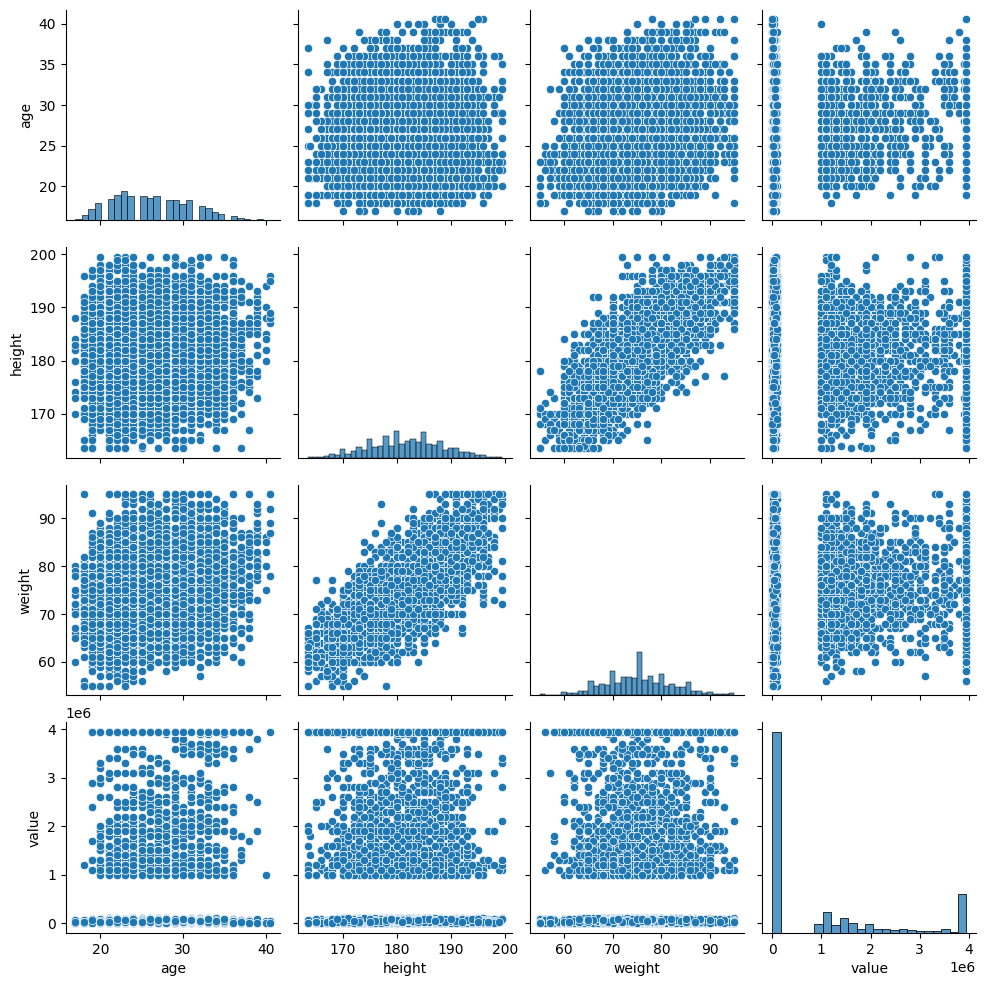

In [30]:
sns.pairplot(df[['age', 'height', 'weight', 'value']])
plt.show()

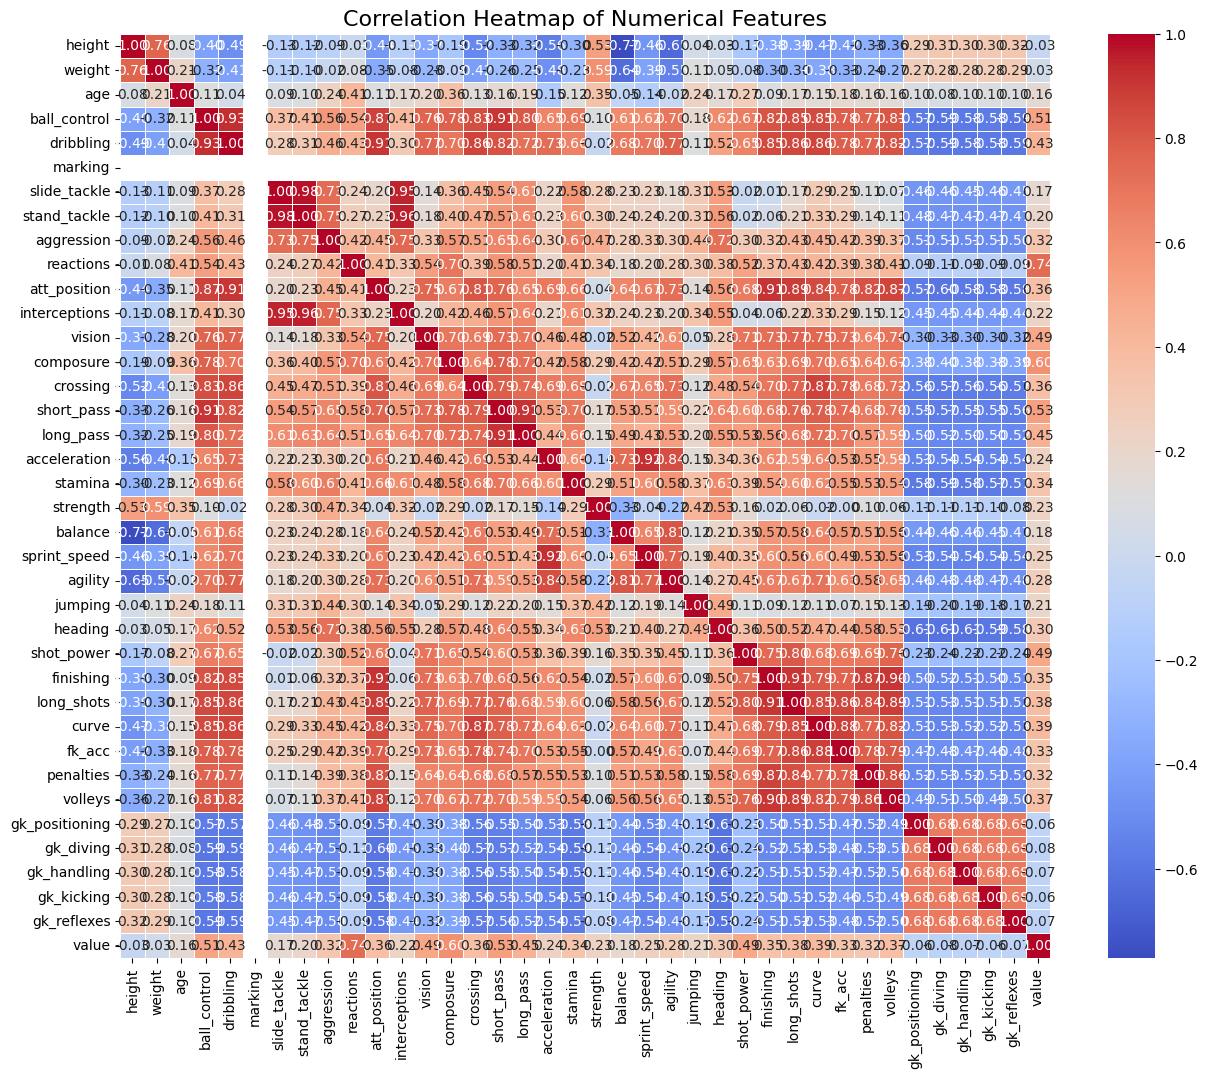

In [31]:
plt.figure(figsize=(15, 12))
numeric_df = df.select_dtypes(include=np.number)
corr = numeric_df.corr()
sns.heatmap(corr, cmap='coolwarm', annot=True, fmt=".2f", linewidths=.5)
plt.title("Correlation Heatmap of Numerical Features", fontsize=16)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

They are most positively correlated with the target variable (value) are identified using correlation analysis. These features have the strongest influence on predicting player market value and are important for model building

##Convert categorical data to numerical data

In [32]:
categorical_columns

Index(['country', 'value'], dtype='object')

In [33]:
## Encoding

from sklearn.preprocessing import LabelEncoder

In [34]:
le_d = {}

In [35]:
for col in categorical_columns:
  le=LabelEncoder()
  df[col]=le.fit_transform(df[col])
  le_d[col]=le

In [36]:
le_d

{'country': LabelEncoder(), 'value': LabelEncoder()}

In [37]:
df.tail()

,country,height,weight,age,ball_control,dribbling,marking,slide_tackle,stand_tackle,aggression,...,curve,fk_acc,penalties,volleys,gk_positioning,gk_diving,gk_handling,gk_kicking,gk_reflexes,value
5677,37,175.0,71.0,31.0,86.0,88.0,NaN,41.0,43.0,63.0,...,84.0,69.0,86.0,83.0,11.0,14.0,14.0,9.0,14.0,90
5678,107,174.0,69.0,31.0,86.0,88.0,NaN,38.0,42.0,75.0,...,77.0,64.0,75.0,75.0,7.0,10.0,10.0,15.0,14.0,90
5679,14,175.0,68.0,31.0,90.0,93.5,NaN,29.0,32.0,63.0,...,88.0,87.0,91.0,86.0,15.0,9.0,9.0,15.0,11.0,90
5680,100,187.0,83.0,38.0,87.0,81.0,NaN,24.0,32.0,62.0,...,79.0,75.0,90.0,85.0,14.0,7.0,11.0,15.0,11.0,90
5681,119,195.0,95.0,40.5,85.0,75.0,NaN,24.0,37.0,84.0,...,79.0,74.0,80.0,87.0,9.0,13.0,15.0,10.0,12.0,90


In [38]:
from sklearn.preprocessing import OrdinalEncoder

# Check available columns to identify a suitable replacement for 'overall'
# print(df.columns)

# Using 'ball_control' as a placeholder for 'overall' for demonstration purposes.
# You might want to create a composite 'overall' score from multiple skill columns
# or choose another single relevant skill column.
df['skill_level'] = pd.cut(df['ball_control'], # Replaced 'overall' with 'ball_control'
                          bins=[0, 50, 75, 100],
                          labels=['Low', 'Medium', 'High'])

ordinal_encoder = OrdinalEncoder(categories=[['Low', 'Medium', 'High']])

df['skill_level_encoded'] = ordinal_encoder.fit_transform(df[['skill_level']])

print(df[['skill_level', 'skill_level_encoded']].head())

  skill_level  skill_level_encoded
0      Medium                  1.0
1      Medium                  1.0
2         Low                  0.0
3         Low                  0.0
4         Low                  0.0


In [39]:
df = pd.get_dummies(df, columns=['country'], drop_first=True)

print(df.head())

   height  weight   age  ball_control  dribbling  marking  slide_tackle  \
0   192.0    84.0  22.0          55.0       43.0      NaN          68.0   
1   181.0    80.0  31.0          69.0       70.0      NaN          56.0   
2   193.0    84.0  29.0          34.0       25.5      NaN          13.0   
3   187.0    86.0  33.0          46.0       48.0      NaN          66.0   
4   191.0    80.0  23.0          34.0       25.5      NaN          14.0   

   stand_tackle  aggression  reactions  ...  country_125  country_126  \
0          73.0        72.0       68.0  ...        False        False   
1          58.0        62.0       70.0  ...        False        False   
2          16.0        27.0       65.0  ...        False        False   
3          69.0        71.0       64.0  ...        False        False   
4          16.0        28.0       50.0  ...        False        False   

   country_127  country_128  country_129  country_130  country_131  \
0        False        False        False

The categorical feature ‘country’ is converted into numerical format using one-hot encoding. This allows machine learning models to process it effectively. One category is dropped to avoid multicollinearity,where false denotes 0 and True denotes 1

## Model building

In [64]:
X = df.drop(['value', 'skill_level', 'marking'], axis=1)   # all input features
y = df['value']                # target variable

In [41]:
print(X.shape)
print(y.shape)

(5682, 172)
(5682,)


In [71]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [43]:
display((X_train.shape, X_test.shape, y_train.shape, y_test.shape))

((4545, 172), (1137, 172), (4545,), (1137,))

In [44]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((4545, 172), (1137, 172), (4545,), (1137,))

Model building is done here by splitting x_train,y_train etc.

In [45]:
# a. Model initialization

from sklearn.linear_model import LinearRegression
lr = LinearRegression()  ## storing the model in an alias name

In [46]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(random_state=42)

In [47]:

y_train_df = y_train.to_frame()
print(y_train_df.head())

      value
43       39
4031     43
1485     27
5227     62
4974     90


In [48]:
for col in X_train.select_dtypes(include=['bool']).columns:
    X_train[col] = X_train[col].astype(int)
for col in X_test.select_dtypes(include=['bool']).columns:
    X_test[col] = X_test[col].astype(int)

model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

Linear regression is performed here.dataframe is formed

In [52]:
## e. Comparison of metrics

from sklearn import metrics

In [54]:
y_pred = model.predict(X_test)

print("MAE: ", metrics.mean_absolute_error(y_test, y_pred))
print("MSE: ", metrics.mean_squared_error(y_test, y_pred))
print("R2 score: ", metrics.r2_score(y_pred, y_test))

MAE:  4.639067722075637
MSE:  42.04505963060686
R2 score:  0.8940027851670824


In [55]:
y_pred = model.predict(X_test)

In [56]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# MSE
mse = mean_squared_error(y_test, y_pred)

# MAE
mae = mean_absolute_error(y_test, y_pred)

# RMSE (optional but important)
rmse = np.sqrt(mse)

# R2 Score
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MSE: 42.04505963060686
MAE: 4.639067722075637
RMSE: 6.4842161924635775
R2 Score: 0.9083419559831138


In [57]:
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

print(comparison.head())

      Actual  Predicted
4434      27      34.32
2133      16      21.92
4174      52      42.17
889       60      59.27
4420      59      56.52


After performing comparison of metrics.the actual and predicted values are compared.

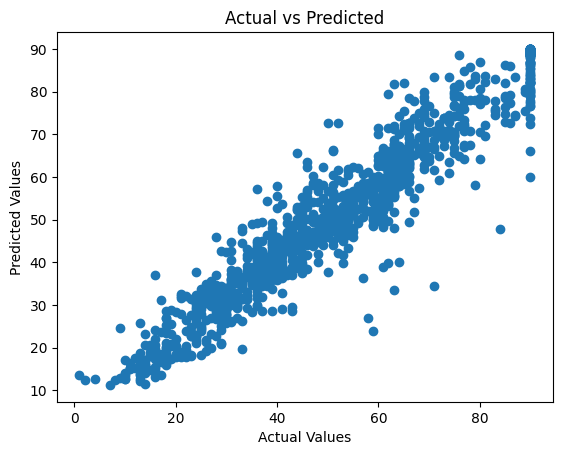

In [58]:
#Scatter plot

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")
plt.show()

##PCA

In [72]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [69]:
from sklearn.decomposition import PCA

In [73]:
pca=PCA()

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

In [76]:
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

In [77]:
##explained variance
explained_variance = pca.explained_variance_ratio_

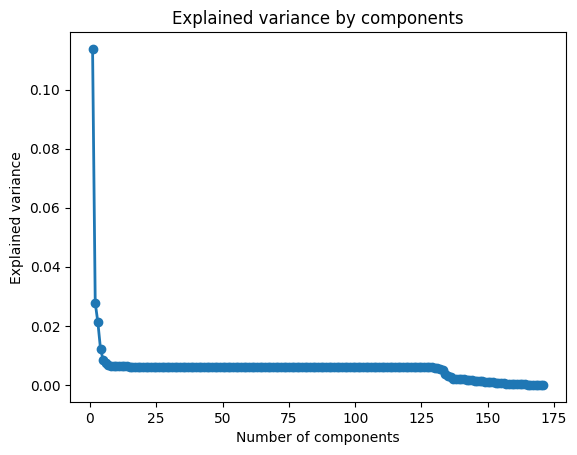

In [78]:
##PLot
plt.figure()
plt.plot(range(1, len(explained_variance)+1), explained_variance, 'o-', linewidth=2)
plt.title('Explained variance by components')
plt.xlabel('Number of components')
plt.ylabel('Explained variance')
plt.show()

##Cumulative Variance Plot

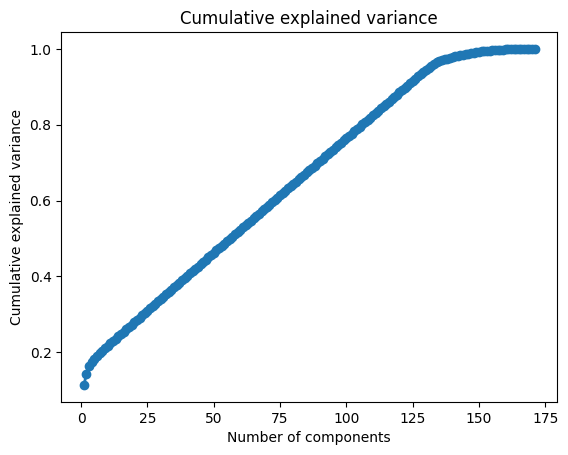

In [82]:
cumulative_variance = np.cumsum(explained_variance)

plt.figure()
plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance,'o-', linewidth=2)
plt.title('Cumulative explained variance')
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')
plt.show()

In [80]:
#select optimal component

n_components = np.argmax(cumulative_variance >= 0.95) + 1

print(f"Optimal number of components: {n_components} ")

Optimal number of components: 131 


In [83]:
#Apply PCA with 130 components

pca = PCA(n_components=130)

# Scale the entire X dataset using the fitted scaler
X_scaled = scaler.transform(X)

#transform the data
X_pca = pca.fit_transform(X_scaled)

In [100]:
X_pca.shape

(5682, 130)

In [85]:
#split the data into train_test_split

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.8, random_state=42)


In [86]:
#Model Building
from sklearn.ensemble import RandomForestClassifier





In [102]:
rf=RandomForestRegressor(random_state=42)

In [103]:
bl_model = rf.fit(X_train,y_train)

In [89]:
bl_y_pred = bl_model.predict(X_test)

In [90]:
#Evaluation metrics:

from sklearn.metrics import confusion_matrix, accuracy_score

In [ ]:
#compare bl_y_pred and y_test

cm= confusion_matrix(y_test, bl_y_pred)
acc = accuracy_score(y_test, bl_y_pred)

print(cm)
print(acc)

#GridSearchCV

In [116]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

In [117]:
#Initialze the GridSearch

grid = GridSearchCV(estimator=rf, param_grid=param_grid1, cv=5)

In [105]:
#Train the GridSearch

grid.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42),
             param_grid={'max_depth': [None, 10, 20],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 150, 50]})

In [111]:
print("Best parameters found by GridSearchCV:")
print(grid.best_params_)

Best parameters found by GridSearchCV:
{'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 150}


In [112]:
print("Best CV score: ",grid.best_score_)

Best CV score:  0.7817326160317034


In [113]:
best_model = grid.best_estimator_
y_pred_tuned = best_model.predict(X_test)

In [114]:
print("R2 Score:", r2_score(y_test, y_pred_tuned))
print("MSE:", mean_squared_error(y_test, y_pred_tuned))
print("MAE:", mean_absolute_error(y_test, y_pred_tuned))

R2 Score: 0.7588860357243048
MSE: 119.30392254748604
MAE: 8.145264193404646


In [118]:
print("Before Tuning:", r2_score(y_test, bl_y_pred))
print("After Tuning:", r2_score(y_test, y_pred_tuned))

Before Tuning: 0.17359252521966917
After Tuning: 0.7588860357243048
